CELL 1 — Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

CELL 2 — Create Dataset

In [2]:
# Set random seed
np.random.seed(42)

# Number of samples
m = 1000

# Generate features
X = np.random.rand(m, 3)

# True weights
true_W = np.array([4, 3, 2])

# Generate target values
y = X.dot(true_W) + 5 + np.random.randn(m) * 0.5

# Reshape y
y = y.reshape(m, 1)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (1000, 3)
Shape of y: (1000, 1)


CELL 3 — Feature Normalization

In [3]:
# Normalize features
X = (X - X.mean(axis=0)) / X.std(axis=0)

print("Normalized Features:")
print(X[:5])

Normalized Features:
[[-0.47939745  1.54151837  0.81811276]
 [ 0.30233913 -1.14208802 -1.15754557]
 [-1.5832143   1.2560416   0.3692025 ]
 [ 0.68398121 -1.59943535  1.6341562 ]
 [ 1.11779049 -0.95189952 -1.06894802]]


CELL 4 — Non-Vectorized Linear Regression

In [4]:
# Initialize parameters
W_nonvec = np.zeros((3, 1))
b_nonvec = 0

# Hyperparameters
learning_rate = 0.01
epochs = 1000

# Number of samples
m = X.shape[0]

# Store losses
losses_nonvec = []

# Start timer
start_time = time.time()

# Gradient Descent
for epoch in range(epochs):

    dW = np.zeros((3, 1))
    db = 0
    loss = 0

    for i in range(m):

        # Prediction
        prediction = np.dot(X[i], W_nonvec).item() + b_nonvec

        # Error
        error = prediction - y[i].item()

        # Loss
        loss += error ** 2

        # Gradients
        for j in range(3):
            dW[j] += error * X[i][j]

        db += error

    # Average gradients
    dW = dW / m
    db = db / m

    # Update parameters
    W_nonvec -= learning_rate * dW
    b_nonvec -= learning_rate * db

    # Compute average loss
    loss = loss / (2 * m)

    losses_nonvec.append(loss)

# End timer
nonvec_time = time.time() - start_time

print("Non-Vectorized Training Time:", nonvec_time)
print("Weights:")
print(W_nonvec)
print("Bias:", b_nonvec)

Non-Vectorized Training Time: 50.98485803604126
Weights:
[[1.15585578]
 [0.88952122]
 [0.57195787]]
Bias: 9.518276523033048


CELL 5 — Vectorized Linear Regression

In [5]:
# Initialize parameters
W_vec = np.zeros((3, 1))
b_vec = 0

# Store losses
losses_vec = []

# Start timer
start_time = time.time()

# Gradient Descent
for epoch in range(epochs):

    # Predictions
    predictions = X.dot(W_vec) + b_vec

    # Errors
    errors = predictions - y

    # Loss
    loss = np.sum(errors ** 2) / (2 * m)

    # Gradients
    dW = X.T.dot(errors) / m
    db = np.sum(errors) / m

    # Update parameters
    W_vec -= learning_rate * dW
    b_vec -= learning_rate * db

    losses_vec.append(loss)

# End timer
vec_time = time.time() - start_time

print("Vectorized Training Time:", vec_time)
print("Weights:")
print(W_vec)
print("Bias:", b_vec)

Vectorized Training Time: 0.2230069637298584
Weights:
[[1.15585578]
 [0.88952122]
 [0.57195787]]
Bias: 9.518276523033048


CELL 6 — Compare Training Time

In [6]:
print("===== Training Time Comparison =====")
print(f"Non-Vectorized Time: {nonvec_time:.4f} seconds")
print(f"Vectorized Time: {vec_time:.4f} seconds")

speedup = nonvec_time / vec_time

print(f"Speedup: {speedup:.2f}x faster")

===== Training Time Comparison =====
Non-Vectorized Time: 50.9849 seconds
Vectorized Time: 0.2230 seconds
Speedup: 228.62x faster


CELL 7 — Plot Loss Curves

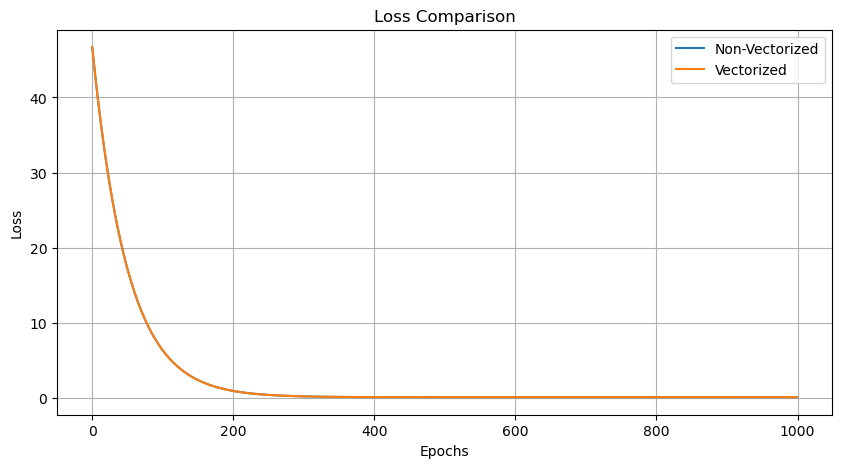

In [7]:
plt.figure(figsize=(10,5))

plt.plot(losses_nonvec, label='Non-Vectorized')
plt.plot(losses_vec, label='Vectorized')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Comparison")

plt.legend()
plt.grid(True)

plt.show()

CELL 8 — Final Comparison

In [8]:
print("===== Final Comparison =====")

print("\nNon-Vectorized Weights:")
print(W_nonvec)

print("\nVectorized Weights:")
print(W_vec)

print("\nNon-Vectorized Final Loss:")
print(losses_nonvec[-1])

print("\nVectorized Final Loss:")
print(losses_vec[-1])

===== Final Comparison =====

Non-Vectorized Weights:
[[1.15585578]
 [0.88952122]
 [0.57195787]]

Vectorized Weights:
[[1.15585578]
 [0.88952122]
 [0.57195787]]

Non-Vectorized Final Loss:
0.12590293649264978

Vectorized Final Loss:
0.12590293649264964
